# 06 — Generalization Eval: Base Gemma vs SFT Gemma · Google Colab

**Phase 2 / Month 2** · MSc Thesis — ECLIPSE project
Supervisor: Dr. Panagiotis Kasnesis | Student: Antonios Bastoulis

---

## What this notebook does

Compares the **base Gemma** (zero-shot, no fine-tuning) against the **SFT Gemma** (LoRA-distilled from SAC, nb 04 + nb 05) on building / week combinations the SFT model **has not been trained on** — i.e. the held-out 2022-dataset buildings (indices 6–11). Both models share the same in-memory weights via PEFT adapter toggling, so only one base-model load is needed per Colab session.

For each config in the eval grid we run four policies:

1. **No-Control** — every battery action = 0.0. The reference baseline that the Challenge KPIs normalise against.
2. **RBC** — `BasicBatteryRBC`, fixed solar-window rule. A non-learning floor.
3. **Base Gemma** — adapter bypassed via `model.disable_adapter()`. CoT prompt (`make_minimal_prompt`).
4. **SFT Gemma** — adapter enabled. No-CoT prompt (`make_sft_prompt`, the one it was trained on).

KPIs come from `src.eval.evaluate / comparison_table / generalisation_gap` (CityLearn 2.6 `evaluate_v2`) so the numbers are directly comparable to nb 01 / nb 04 / nb 05.

## Why adapter toggling, not two separate model loads

Gemma-4 E4B in 4-bit is ~9.5 GB — two copies don't fit in a 16 GB T4 / 22 GB L4. PEFT's `model.disable_adapter()` is a context manager that routes the forward pass through the base weights for the duration of that block, then restores LoRA-enabled forwarding when the block exits. Net effect: one model in VRAM, two behaviours — and one shared model load (~5 min) instead of two.

## § 0 — Config
> Edit this cell only.

In [ ]:
import os, sys, subprocess, time, warnings, json, random
import numpy as np

# ── Repo ─────────────────────────────────────────────────────────────────
GITHUB_REPO = "https://github.com/antonisbast/eclipse-thesis.git"
REPO_DIR    = "/content/eclipse-thesis"

# ── Model + adapter ──────────────────────────────────────────────────────
MODEL_ID:       str  = "unsloth/gemma-4-E4B-it"
LOAD_IN_4BIT:   bool = True
MAX_SEQ_LEN:    int  = 1024
MAX_NEW_TOKENS: int  = 200

# nb 05 V5 § 12 backs up the trained LoRA to .../sft_adaptersV5/lora_adapter
ADAPTER_PATH = "/content/drive/MyDrive/eclipse-thesis/sft_adaptersV6/lora_adapter"
ADAPTER_TAG  = "v6"   # label suffix that appears in result tables

# ── CityLearn version ────────────────────────────────────────────────────
# 2.6 introduces evaluate_v2(); our src/eval.py depends on it.
CITYLEARN_VERSION = "2.6.0b2"

# ── Eval grid ────────────────────────────────────────────────────────────
# The SFT'd adapter was trained on 3-bldg slices over the FULL year and
# buildings TRAINING_BUILDINGS=[0,1,2] ∪ HELDOUT_BUILDINGS=[3,4,5]. To make a
# fair "did SFT generalise?" comparison, EVERY eval config below uses
# buildings the SFT model has NEVER seen — indices 6–11 of the 2022 dataset.
#
# Each config keeps width=3 so the prompt geometry (3 action lines) matches
# the SFT training distribution. Buildings inside a single config can be any
# subset of [6..11].
#
# Time window: 1 week (168 hourly steps) per rollout. Each SLM rollout takes
# ~50–60 min on Colab L4 / ~110 min on T4. With base + SFT per config, that's
# 2 × ~60 min = ~2 h per config — leave plenty of session time before adding
# more configs.
EVAL_LEN: int = 168    # 1 week

# Season midpoints (2022 dataset starts at month 7, hour 0):
#   summer ≈ t=1100   autumn ≈ t=3300   winter ≈ t=5500   spring ≈ t=7700
CONFIGS = [
    #{"name": "summer_unseen_a", "start": 1100, "buildings": [6, 7, 8]},
    {"name": "winter_unseen_a", "start": 5500, "buildings": [6, 7, 8]},
    # Add more once the first run completes — examples:
    # {"name": "summer_unseen_b", "start": 1100, "buildings": [9, 10, 11]},
    # {"name": "winter_unseen_b", "start": 5500, "buildings": [9, 10, 11]},
]

# ── Misc ─────────────────────────────────────────────────────────────────
HF_TOKEN: str = ""
SEED          = 42

import torch
if torch.cuda.is_available():
    g = torch.cuda.get_device_properties(0)
    print(f"✓ GPU: {g.name}  ({g.total_memory/1e9:.1f} GB VRAM)")
else:
    print("⚠ No GPU — set Runtime → Change runtime type → T4/L4")

# Wall-time estimate: per config we run no-op + RBC (seconds) + base SLM + SFT SLM.
# SLM rollouts dominate; budget ~60 min each on L4 at 168 steps.
n_slm_rollouts = 2 * len(CONFIGS)
est_min        = n_slm_rollouts * (EVAL_LEN / 168) * 60
print(f"Grid: {len(CONFIGS)} configs × (No-Control + RBC + Base SLM + SFT SLM)")
print(f"      {n_slm_rollouts} SLM rollouts total ≈ {est_min:.0f} min wall time on L4")


✓ GPU: Tesla T4  (15.6 GB VRAM)
Grid: 1 configs × (No-Control + RBC + Base SLM + SFT SLM)
      2 SLM rollouts total ≈ 120 min wall time on L4


## § 1 — Installs (CityLearn 2.6.0b2 + Unsloth Gemma-4 stack)

CityLearn pinned to **2.6.0b2** (`src.eval` uses `evaluate_v2()`), then the
**Unsloth Gemma-4 stack** — the *same* install as nb 05, with `transformers`
pinned to `5.5.0`. Loading the base Gemma through Unsloth's `FastModel` (rather
than plain `transformers` 4-bit) means this eval runs on the exact patched
kernels nb 05 trained the LoRA adapter against — no train/eval kernel drift.

In [ ]:
# CityLearn 2.6 is a pre-release on PyPI — pin the version explicitly.
# --no-deps because CityLearn pulls heavy/legacy deps we don't need at eval
# time (e.g. some EnergyPlus extras). We install the runtime deps explicitly.
!pip install -q numpy gymnasium doe-xstock nrel-pysam
!pip install -q --pre "CityLearn=={CITYLEARN_VERSION}" --no-deps

import citylearn
assert citylearn.__version__.startswith("2.6"), (
    f"Expected CityLearn 2.6.x, got {citylearn.__version__}. "
    f"src.eval depends on evaluate_v2() which only exists in 2.6+."
)
print(f"✓ CityLearn {citylearn.__version__}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 5.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.6/423.6 kB 11.3 MB/s eta 0:00:00
✓ CityLearn 2.6.0b2


In [ ]:
# Unsloth + Gemma-4 stack — SAME install as nb 05, so the base Gemma here is
# loaded on the exact Unsloth-patched kernels nb 05 trained against. Loading
# with plain AutoModelForCausalLM (the old path) would eval the SFT adapter on
# different attention/RoPE code than it was trained on.
# transformers is PINNED to 5.5.0 — unsloth-zoo hard-caps it at <=5.5.0; an
# unpinned `--upgrade` pulls 5.8.x and the Gemma-4 patch breaks.
import os, re, torch

_v = re.match(r"[\d]+\.[\d]+", str(torch.__version__)).group(0)
_xformers = "xformers==" + {"2.10": "0.0.34", "2.9": "0.0.33.post1",
                            "2.8": "0.0.32.post2"}.get(_v, "0.0.34")

!pip install -q sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
!pip install -q --no-deps unsloth_zoo bitsandbytes accelerate {_xformers} peft trl triton unsloth
!pip install -q --no-deps --upgrade "torchao>=0.16.0"
!pip install -q --no-deps transformers==5.5.0 "tokenizers>=0.22.0,<=0.23.0"
!pip install -q torchcodec
!pip install -q --no-deps --upgrade timm

torch._dynamo.config.recompile_limit = 64

import unsloth                       # triggers Unsloth's model patching
import transformers
print(f"✓ ML dependencies installed  |  transformers=={transformers.__version__}")
assert transformers.__version__.startswith("5.5"), (
    f"transformers is {transformers.__version__}, expected 5.5.x — re-run this cell."
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 12.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.8/110.8 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 428.0/428.0 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.4/67.4 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 100.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/

## § 2 — Clone repo + mount Drive

In [ ]:
if not os.path.exists(REPO_DIR):
    res = subprocess.run(["git", "clone", GITHUB_REPO, REPO_DIR], capture_output=True, text=True)
    print(res.stdout or res.stderr)
else:
    res = subprocess.run(["git", "-C", REPO_DIR, "pull"], capture_output=True, text=True)
    print("Repo present —", res.stdout.strip() or "up to date")

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

from google.colab import drive
drive.mount('/content/drive')

assert os.path.isdir(ADAPTER_PATH), (
    f"Adapter not found at {ADAPTER_PATH}.\n"
    f"Inspect candidates:  !ls /content/drive/MyDrive/eclipse-thesis/sft_adaptersV5/"
)
print(f"✓ Adapter found at {ADAPTER_PATH}")

Repo present — Already up to date.
Mounted at /content/drive
✓ Adapter found at /content/drive/MyDrive/eclipse-thesis/sft_adaptersV6/lora_adapter


## § 3 — Load Base Gemma (Unsloth `FastModel`, 4-bit) + Attach the Saved LoRA

`FastModel.from_pretrained` pulls the base Gemma from HF Hub in `bitsandbytes` 4-bit and patches in Unsloth's kernels — the **same path nb 05 used to train the adapter**, so the eval and the training run share identical attention / RoPE code. `get_chat_template(tokenizer, "gemma-4")` then pins the inference chat template to exactly the one training rendered.

Once the base is in VRAM, `PeftModel.from_pretrained(base, ADAPTER_PATH)` attaches the nb 05 LoRA **in place** on the same object. The resulting `model` is a `PeftModel`: its `disable_adapter()` context manager routes the forward through the base weights for the duration of that block, then restores LoRA-enabled forwarding. Net effect: one model in VRAM (~9.5 GB for Gemma-4 E4B in 4-bit), two behaviours, one shared load.

In [ ]:
from unsloth import FastModel
from unsloth.chat_templates import get_chat_template
from peft import PeftModel
import torch, time

torch.cuda.empty_cache()

# Load the base Gemma via Unsloth FastModel — the SAME patched kernels nb 05
# trained the adapter against. (Loading with plain AutoModelForCausalLM would
# run the SFT adapter on different attention/RoPE code than training used.)
_t0 = time.time()
model, tokenizer = FastModel.from_pretrained(
    model_name      = MODEL_ID,
    max_seq_length  = MAX_SEQ_LEN,
    dtype           = None,            # Unsloth auto-detects precision
    load_in_4bit    = LOAD_IN_4BIT,
    full_finetuning = False,
    token           = HF_TOKEN or None,
)
print(f"Base model loaded in {time.time()-_t0:.1f}s")

# Render inference with the exact chat template nb 05 trained against.
tokenizer = get_chat_template(tokenizer, chat_template="gemma-4")

# Attach the nb 05 LoRA in-place. The result is a PeftModel — its
# disable_adapter() context manager routes the forward through the base
# weights, which is what the base-vs-SFT toggle in § 4 relies on.
_t0 = time.time()
model = PeftModel.from_pretrained(model, ADAPTER_PATH)
model.eval()
print(f"LoRA adapter attached in {time.time()-_t0:.1f}s")

# Guard: a missing disable_adapter() would silently make the "base" rollout
# identical to the SFT rollout — fail loud instead.
assert hasattr(model, "disable_adapter"), (
    "Loaded model has no disable_adapter() — the base-vs-SFT toggle in § 4 "
    "needs it. Check the peft / Unsloth versions installed in § 1."
)
print(f"✓ Ready — GPU mem: {torch.cuda.memory_allocated()/1e9:.1f} GB")

==((====))==  Unsloth 2026.5.2: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/203 [00:00<?, ?B/s]

processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

Base model loaded in 374.8s
LoRA adapter attached in 5.9s
✓ Ready — GPU mem: 11.1 GB


## § 4 — Build Base + SFT Providers (`src.providers.LocalHFProvider`)

Both providers wrap the **same** in-memory model object — only their constructor flags differ. The unified `LocalHFProvider` (the same class nb 03 uses for zero-shot SLMs and nb 05 uses for the post-SFT eval) takes `model=` / `tokenizer=` to skip re-loading and `disable_adapter=True` to route the forward through the base weights.

- `slm_sft`  — adapter enabled, prompt = `make_sft_prompt` (no-CoT, exactly what the model was trained on).
- `slm_base` — `disable_adapter=True`, prompt = `make_minimal_prompt` (CoT, the canonical zero-shot prompt the base Gemma has never been fine-tuned to ignore).

Picking the prompt that matches each model's training distribution is critical — using the wrong one is OOD and degrades sharply (see nb 05 § 19).

In [ ]:
from src.providers import LocalHFProvider
from src.sft       import make_sft_prompt
from src.agent     import make_minimal_prompt

# SFT provider: adapter enabled, no-CoT prompt (matches SFT training).
slm_sft = LocalHFProvider(
    model           = model,
    tokenizer       = tokenizer,
    model_id        = MODEL_ID,
    max_new_tokens  = MAX_NEW_TOKENS,
    prompt_builder  = make_sft_prompt,
    label           = f"sft_{ADAPTER_TAG}:{MODEL_ID.split('/')[-1]}",
)

# Base provider: SAME model object, but disable_adapter=True so every forward
# bypasses the LoRA → pure base Gemma. CoT prompt is the canonical zero-shot
# prompt (the base model has never seen the no-CoT SFT prompt).
slm_base = LocalHFProvider(
    model           = model,
    tokenizer       = tokenizer,
    model_id        = MODEL_ID,
    max_new_tokens  = MAX_NEW_TOKENS,
    prompt_builder  = make_minimal_prompt,
    disable_adapter = True,
    label           = f"base:{MODEL_ID.split('/')[-1]}",
)

# Ordered dict — table columns and plot panels follow this order downstream.
SLM_PROVIDERS = {"base": slm_base, "sft": slm_sft}
for tag, p in SLM_PROVIDERS.items():
    print(f"  [{tag:>4s}] {p.label}  (prompt={p.prompt_builder.__name__}, disable_adapter={p.disable_adapter})")


  Gemma detected — system prompt merged into user message
  Gemma detected — system prompt merged into user message
  disable_adapter=True — every forward bypasses the LoRA
  [base] base:gemma-4-E4B-it  (prompt=make_minimal_prompt, disable_adapter=True)
  [ sft] sft_v6:gemma-4-E4B-it  (prompt=make_sft_prompt, disable_adapter=False)


## § 5 — Env Factory + Rollout Helpers

`make_eval_env` defers to `src.env.make_env` so every config in the grid uses the SAME local-path schema and reward function as nb 04 (where the SFT teacher was trained). The repo was cloned in § 2, so the data tree is already on disk.

`run_slm_rollout(cfg, provider)` is parameterised on the provider — same loop drives both the base and the SFT rollouts, with the only difference being which provider is passed in. Per step it logs the model's action-token output for the per-config distribution plot in § 9.

In [ ]:
import re
from citylearn.citylearn   import CityLearnEnv
from citylearn.agents.rbc  import BasicBatteryRBC
from src.env  import make_env, snapshot_state
from src.sft  import render_state
from src.eval import evaluate, comparison_table, generalisation_gap, EvalResult

warnings.filterwarnings("ignore")
np.random.seed(SEED); random.seed(SEED)

# src.env.make_env loads the local schema patched to an absolute path —
# same dataset/schema nb 04 used to train SAC and nb 05 used for SFT.
def make_eval_env(start: int, length: int, buildings: list[int]) -> CityLearnEnv:
    return make_env(
        buildings = buildings,
        start     = start,
        end       = start + length - 1,
        reward_fn = "merlin",
    )


# Extracts CHARGE_X / IDLE / DISCHARGE_X tokens from the raw SLM response —
# powers the per-config action-mix table in § 9.
_TOK_RE = re.compile(r"<action building=\d+>([A-Z_0-9]+)</action>")


def run_slm_rollout(cfg: dict, provider, tag: str) -> dict:
    """One SLM rollout for one config × one provider (base or SFT).

    The provider already carries the right prompt_builder (CoT for base,
    no-CoT for SFT) and the adapter-toggle flag — same loop for both.
    """
    import collections
    buildings = cfg["buildings"]
    n_b       = len(buildings)
    env       = make_eval_env(cfg["start"], EVAL_LEN, buildings)
    env.reset()

    tokens = collections.Counter()
    n_fb   = 0
    t0     = time.time()
    done, t = False, 0
    while not done:
        snap = snapshot_state(env)
        acts, raw, fb = provider.step(render_state(snap), n_buildings=n_b)
        n_fb += int(fb)
        tokens.update(_TOK_RE.findall(raw))
        _, _, term, trunc, _ = env.step([[float(a)] for a in acts])
        done = bool(term or trunc)
        if t % 48 == 0:
            print(f"    [{cfg['name']}/{tag}] t={t:4d}/{EVAL_LEN}  fb={n_fb}  {time.time()-t0:.0f}s")
        t += 1
    elapsed = time.time() - t0
    print(f"    [{cfg['name']}/{tag}] done in {elapsed:.0f}s | fallbacks={n_fb}/{t}")
    return {"env": env, "tokens": tokens, "fb": n_fb, "elapsed": elapsed}


def run_rbc_rollout(cfg: dict) -> CityLearnEnv:
    env = make_eval_env(cfg["start"], EVAL_LEN, cfg["buildings"])
    BasicBatteryRBC(env=env).learn(episodes=1)
    return env


def run_noop_rollout(cfg: dict) -> CityLearnEnv:
    env = make_eval_env(cfg["start"], EVAL_LEN, cfg["buildings"])
    env.reset()
    n_b  = len(cfg["buildings"])
    done = False
    while not done:
        _, _, term, trunc, _ = env.step([[0.0] for _ in range(n_b)])
        done = bool(term or trunc)
    return env


print(f"CityLearn {citylearn.__version__}  |  {len(CONFIGS)} configs × 2 SLM providers queued")


CityLearn 2.6.0b2  |  1 configs × 2 SLM providers queued


In [ ]:
import inspect
import textwrap
import transformers.processing_utils

# Dynamically patch the apply_chat_template bug in transformers
source = inspect.getsource(transformers.processing_utils.ProcessorMixin.apply_chat_template)
source = textwrap.dedent(source)  # Fix IndentationError from class method extraction
source = source.replace(
    'if content["type"] in ["image", "video"]',
    'if isinstance(content, dict) and content.get("type") in ["image", "video"]'
)

exec_globals = transformers.processing_utils.__dict__.copy()
exec(source, exec_globals)
transformers.processing_utils.ProcessorMixin.apply_chat_template = exec_globals['apply_chat_template']
print("✓ Patched transformers.processing_utils.ProcessorMixin.apply_chat_template")

✓ Patched transformers.processing_utils.ProcessorMixin.apply_chat_template


## § 6 — Run the Grid

Per config: no-op + RBC + one rollout per entry in `SLM_PROVIDERS` (`base`, `sft`). Each rollout is converted to an `EvalResult` via `src.eval.evaluate` so the KPI extraction matches everywhere in the codebase. Tokens and fallback counts are cached on the config dict so § 9 / § 11 can replay them without re-rolling.

In [ ]:
import pandas as pd

POLICY_ORDER = ["No-Control", "RBC"] + [p.label for p in SLM_PROVIDERS.values()]

for cfg in CONFIGS:
    print(f"\n{'='*64}\n {cfg['name']}  |  start={cfg['start']}  buildings={cfg['buildings']}  steps={EVAL_LEN}\n{'='*64}")

    print("  No-Control …");  env_no  = run_noop_rollout(cfg)
    print("  RBC …");         env_rbc = run_rbc_rollout(cfg)

    slm_envs:    dict[str, CityLearnEnv] = {}
    slm_outs:    dict[str, dict]         = {}
    for tag, provider in SLM_PROVIDERS.items():
        print(f"  SLM/{tag} ({provider.label}) …")
        out = run_slm_rollout(cfg, provider, tag)
        slm_envs[tag] = out["env"]
        slm_outs[tag] = out

    # Build EvalResults — one per (config × policy)
    res_noop = evaluate(env_no,  label=f"No-Control@{cfg['name']}")
    res_rbc  = evaluate(env_rbc, label=f"RBC@{cfg['name']}")
    res_slms = {
        tag: evaluate(env, label=f"{SLM_PROVIDERS[tag].label}@{cfg['name']}")
        for tag, env in slm_envs.items()
    }

    cfg["_envs"]    = {"No-Control": env_no, "RBC": env_rbc,
                       **{SLM_PROVIDERS[tag].label: env for tag, env in slm_envs.items()}}
    cfg["_results"] = {"No-Control": res_noop, "RBC": res_rbc,
                       **{SLM_PROVIDERS[tag].label: res for tag, res in res_slms.items()}}
    cfg["_tokens"]  = {tag: out["tokens"] for tag, out in slm_outs.items()}
    cfg["_fb"]      = {tag: out["fb"]     for tag, out in slm_outs.items()}
    cfg["_t_sec"]   = {tag: out["elapsed"] for tag, out in slm_outs.items()}

    for tag, toks in cfg["_tokens"].items():
        print(f"  action tokens ({tag}): {dict(toks)}")

total_slm_min = sum(t for cfg in CONFIGS for t in cfg['_t_sec'].values()) / 60
print(f"\n✓ Grid complete. Total SLM wall time: {total_slm_min:.1f} min")



 winter_unseen_a  |  start=5500  buildings=[6, 7, 8]  steps=168
  No-Control …
  RBC …
  SLM/base (base:gemma-4-E4B-it) …
    [winter_unseen_a/base] t=   0/168  fb=0  49s
    [winter_unseen_a/base] t=  48/168  fb=0  721s
    [winter_unseen_a/base] t=  96/168  fb=0  1400s
    [winter_unseen_a/base] t= 144/168  fb=0  2077s
    [winter_unseen_a/base] done in 2386s | fallbacks=0/167
  SLM/sft (sft_v6:gemma-4-E4B-it) …
    [winter_unseen_a/sft] t=   0/168  fb=0  19s
    [winter_unseen_a/sft] t=  48/168  fb=0  429s
    [winter_unseen_a/sft] t=  96/168  fb=0  841s
    [winter_unseen_a/sft] t= 144/168  fb=0  1247s
    [winter_unseen_a/sft] done in 1432s | fallbacks=0/167
  action tokens (base): {'CHARGE_40': 54, 'CHARGE_20': 58, 'IDLE': 295, 'DISCHARGE_40': 27, 'DISCHARGE_20': 55, 'CHARGE_60': 6, 'DISCHARGE_80': 1, 'DISCHARGE_60': 5}
  action tokens (sft): {'IDLE': 494, 'DISCHARGE_20': 5, 'DISCHARGE_40': 2}

✓ Grid complete. Total SLM wall time: 63.6 min


## § 7 — Challenge & ZNE tables (via `src.eval.comparison_table`)
One Challenge-score table and one ZNE table per config. Indexed by agent
label, columns are the canonical KPIs the rest of the codebase uses.

In [ ]:
for cfg in CONFIGS:
    name = cfg['name']
    print(f"\n── {name}  (start={cfg['start']}, buildings={cfg['buildings']}) ──")
    chal_df, zne_df = comparison_table(list(cfg["_results"].values()))
    print("Challenge scores (lower is better):")
    display(chal_df)
    print("ZNE / self-consumption:")
    display(zne_df[["ZNE ratio (solar / import)", "self-consumption ratio"]])


── winter_unseen_a  (start=5500, buildings=[6, 7, 8]) ──
Challenge scores (lower is better):


,C — cost,G — carbon,R — ramping,1L — load factor,Phase I (C+G)/2,Combined (C+G+D)/3
No-Control@winter_unseen_a,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
RBC@winter_unseen_a,0.3158,0.9952,1.0412,0.9798,0.6555,0.7738
base:gemma-4-E4B-it@winter_unseen_a,-0.8951,1.4450,1.9795,0.9809,0.2750,0.6767
sft_v6:gemma-4-E4B-it@winter_unseen_a,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


ZNE / self-consumption:


,ZNE ratio (solar / import),self-consumption ratio
No-Control@winter_unseen_a,1.9027,0.4232
RBC@winter_unseen_a,1.9443,0.5088
base:gemma-4-E4B-it@winter_unseen_a,1.2575,0.3862
sft_v6:gemma-4-E4B-it@winter_unseen_a,1.9027,0.4232


## § 7.1 — Cross-Config Summary (Phase I + ZNE per policy per config)

One row per (config × policy). The headline question for this notebook is **how does `sft` compare to `base` on the same unseen buildings?** — answered by the `Δ Phase I` delta at the bottom (negative = SFT beats base = distillation transferred to unseen buildings).

In [ ]:
rows = []
for cfg in CONFIGS:
    for policy_lbl, res in cfg['_results'].items():
        rows.append({
            "config":              cfg['name'],
            "policy":              policy_lbl,
            "C  — cost":           res.challenge["C  — cost"],
            "G  — carbon":         res.challenge["G  — carbon"],
            "R  — ramping":        res.challenge["R  — ramping"],
            "1L — load factor":    res.challenge["1L — load factor"],
            "Phase I":             res.challenge["Phase I (C+G)/2"],
            "Combined":            res.challenge["Combined (C+G+D)/3"],
            "ZNE ratio":           res.zne["ZNE ratio (solar / import)"],
            "self-consumption":    res.zne["self-consumption ratio"],
        })

summary_df = pd.DataFrame(rows).set_index(["config", "policy"]).round(4)
print("Cross-config Phase-I + ZNE summary:")
display(summary_df)

# ── Headline deltas ───────────────────────────────────────────────────────
# SFT vs Base: did fine-tuning help on unseen buildings? (negative = yes)
# SFT vs RBC : did the fine-tuned SLM clear the rule-based floor?
base_label = slm_base.label
sft_label  = slm_sft.label

phase_i = summary_df["Phase I"].unstack("policy")
deltas = pd.DataFrame({
    "Δ Phase I (SFT − Base)": phase_i[sft_label] - phase_i[base_label],
    "Δ Phase I (SFT − RBC)":  phase_i[sft_label] - phase_i["RBC"],
}).round(4)
print("\nHeadline deltas — negative = first agent beats second:")
display(deltas)


Cross-config Phase-I + ZNE summary:


C  — cost  G  — carbon  R  — ramping  \
config          policy                                                        
winter_unseen_a No-Control                1.0000       1.0000        1.0000   
                RBC                       0.3158       0.9952        1.0412   
                base:gemma-4-E4B-it      -0.8951       1.4450        1.9795   
                sft_v6:gemma-4-E4B-it     1.0000       1.0000        1.0000   

                                       1L — load factor  Phase I  Combined  \
config          policy                                                       
winter_unseen_a No-Control                       1.0000   1.0000    1.0000   
                RBC                              0.9798   0.6555    0.7738   
                base:gemma-4-E4B-it              0.9809   0.2750    0.6767   
                sft_v6:gemma-4-E4B-it            1.0000   1.0000    1.0000   

                                       ZNE ratio  self-consumption  
config          policy                                              
winter_unseen_a No-Control                1.9027            0.4232  
                RBC                       1.9443            0.5088  
                base:gemma-4-E4B-it       1.2575            0.3862  
                sft_v6:gemma-4-E4B-it     1.9027            0.4232


Headline deltas — negative = first agent beats second:


,Δ Phase I (SFT − Base),Δ Phase I (SFT − RBC)
config,,
winter_unseen_a,0.725,0.3445


## § 8 — Cross-Config Spread

`src.eval.generalisation_gap` was designed for an explicit (train-buildings, unseen-buildings) pair. In this notebook *every* config is on unseen buildings, so the relevant comparison is the spread of each policy's score across configs — how stable is the SFT model when only the season / building subset changes? A tight spread on `sft` and a wide spread on `base` would mean SFT made the policy more robust.

In [ ]:
if len(CONFIGS) < 2:
    print("Need ≥ 2 configs in the eval grid to measure spread.")
else:
    spread = pd.DataFrame({
        "Phase I (mean)": phase_i.mean(axis=0),
        "Phase I (std)":  phase_i.std (axis=0),
        "Phase I (min)":  phase_i.min (axis=0),
        "Phase I (max)":  phase_i.max (axis=0),
    }).round(4)
    print("Per-policy Phase-I spread across configs (lower mean = better, lower std = more robust):")
    display(spread)


Need ≥ 2 configs in the eval grid to measure spread.


## § 9 — Action Distribution per (Config × Provider)

The base Gemma and SFT Gemma should produce visibly different action mixes. The SFT model was distilled from SAC, whose policy on this dataset is heavily biased toward `DISCHARGE_20` / `IDLE` / `CHARGE_20` (small actions dominate the optimum). A `base` row that's mostly `CHARGE_100` / `DISCHARGE_100` or stuck on `IDLE` is the expected zero-shot behaviour; the `sft` row should look much more like the teacher's distribution.

In [ ]:
TOKEN_ORDER = ["CHARGE_100","CHARGE_80","CHARGE_60","CHARGE_40","CHARGE_20",
               "IDLE",
               "DISCHARGE_20","DISCHARGE_40","DISCHARGE_60","DISCHARGE_80","DISCHARGE_100"]

rows = []
for cfg in CONFIGS:
    for tag in SLM_PROVIDERS:
        tot = sum(cfg["_tokens"][tag].values()) or 1
        row = {"config": cfg["name"], "provider": tag}
        for tok in TOKEN_ORDER:
            row[tok] = round(100 * cfg["_tokens"][tag].get(tok, 0) / tot, 1)
        row["fallbacks"] = cfg["_fb"][tag]
        rows.append(row)

action_df = pd.DataFrame(rows).set_index(["config", "provider"])
print("Action-token distribution per (config × provider) — %:")
display(action_df)

summary_actions = pd.DataFrame({
    "CHARGE %":    action_df[[c for c in action_df.columns if c.startswith("CHARGE")]].sum(axis=1),
    "IDLE %":      action_df["IDLE"],
    "DISCHARGE %": action_df[[c for c in action_df.columns if c.startswith("DISCHARGE")]].sum(axis=1),
}).round(1)
print("\nCoarse charge / idle / discharge split:")
display(summary_actions)


Action-token distribution per (config × provider) — %:


CHARGE_100  CHARGE_80  CHARGE_60  CHARGE_40  \
config          provider                                                
winter_unseen_a base             0.0        0.0        1.2       10.8   
                sft              0.0        0.0        0.0        0.0   

                          CHARGE_20  IDLE  DISCHARGE_20  DISCHARGE_40  \
config          provider                                                
winter_unseen_a base           11.6  58.9          11.0           5.4   
                sft             0.0  98.6           1.0           0.4   

                          DISCHARGE_60  DISCHARGE_80  DISCHARGE_100  fallbacks  
config          provider                                                        
winter_unseen_a base               1.0           0.2            0.0          0  
                sft                0.0           0.0            0.0          0


Coarse charge / idle / discharge split:


CHARGE %  IDLE %  DISCHARGE %
config          provider                               
winter_unseen_a base          23.6    58.9         17.6
                sft            0.0    98.6          1.4

## § 10 — Plots: Action Mix + SoC Traces

Two visualisations:

1. **Action-mix bar chart** — stacked CHARGE / IDLE / DISCHARGE percentages per (config × provider). Visually answers "did SFT change what the model does?".
2. **SoC traces** — one subplot per config, two panels per subplot (base vs SFT). Reveals whether either policy actually moves the battery — flat SoC means the agent is parking at IDLE and the reward gap is mostly RBC vs no-op, not SLM vs anything.

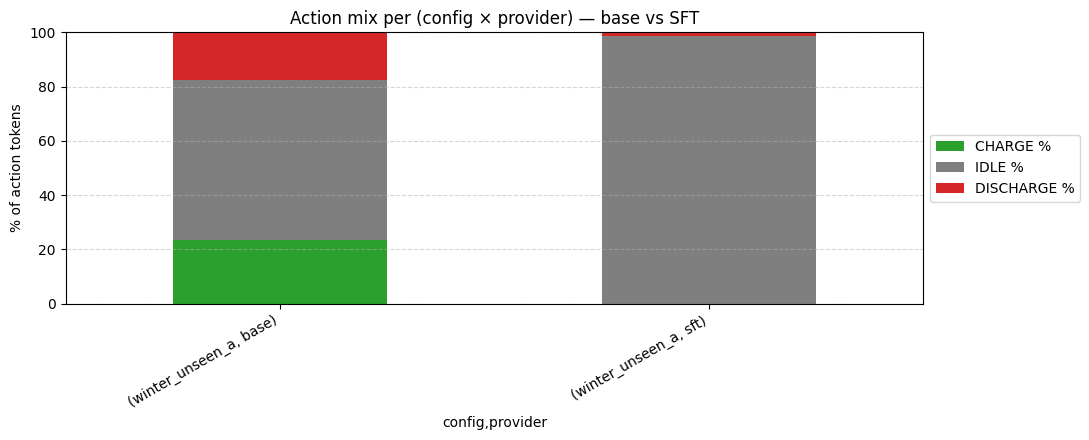

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4.5))
summary_actions.plot(kind="bar", stacked=True, ax=ax,
                     color=["#2ca02c", "#7f7f7f", "#d62728"])
ax.set_ylabel("% of action tokens")
ax.set_title("Action mix per (config × provider) — base vs SFT")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


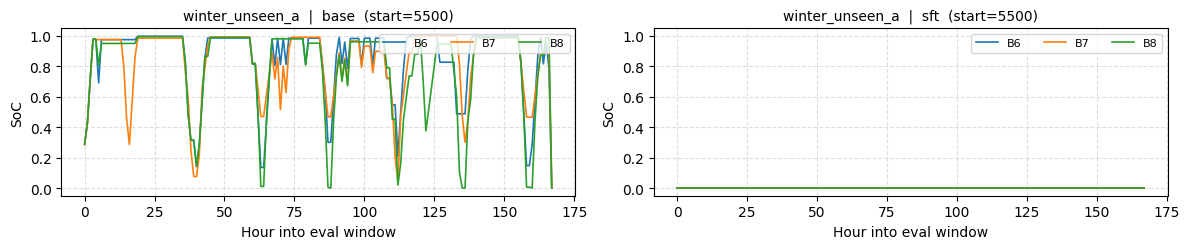

In [ ]:
# One row per config, one column per SLM provider (base | sft).
n_cfg = len(CONFIGS)
n_prov = len(SLM_PROVIDERS)
fig, axes = plt.subplots(nrows=n_cfg, ncols=n_prov,
                         figsize=(6 * n_prov, 2.6 * n_cfg),
                         sharex="col")
if n_cfg == 1:
    axes = np.array([axes])
if n_prov == 1:
    axes = axes.reshape(-1, 1)

for r, cfg in enumerate(CONFIGS):
    for c, (tag, provider) in enumerate(SLM_PROVIDERS.items()):
        ax  = axes[r, c]
        env = cfg["_envs"][provider.label]
        for i, b in enumerate(env.buildings):
            ax.plot(b.electrical_storage.soc, label=f"B{cfg['buildings'][i]}", lw=1.2)
        ax.set_ylim(-0.05, 1.05)
        ax.set_ylabel("SoC")
        ax.set_title(f"{cfg['name']}  |  {tag}  (start={cfg['start']})", fontsize=10)
        ax.legend(loc="upper right", ncol=len(cfg["buildings"]), fontsize=8)
        ax.grid(linestyle="--", alpha=0.4)

for ax in axes[-1, :]:
    ax.set_xlabel("Hour into eval window")

plt.tight_layout()
plt.show()


## § 11 — Persist to Drive

Save every artefact needed to remake the comparison plots without re-running the SLMs: the cross-config summary, the action-mix DataFrames (per-config × provider), the per-config Challenge / ZNE tables, and a manifest with model / adapter paths, eval window, wall-time per provider, and fallback counts. All filenames are timestamped under `eval_runs/{ADAPTER_TAG}_base_vs_sft_<stamp>/` so re-runs never overwrite an earlier experiment.

In [ ]:
from pathlib import Path

stamp   = time.strftime("%Y%m%d_%H%M%S")
out_dir = Path(f"/content/drive/MyDrive/eclipse-thesis/eval_runs/{ADAPTER_TAG}_base_vs_sft_{stamp}")
out_dir.mkdir(parents=True, exist_ok=True)

summary_df.to_csv     (out_dir / "summary_cross_config.csv")
action_df.to_csv      (out_dir / "action_distribution.csv")
summary_actions.to_csv(out_dir / "action_summary.csv")
deltas.to_csv         (out_dir / "headline_deltas.csv")
if len(CONFIGS) >= 2:
    spread.to_csv     (out_dir / "phase1_spread.csv")

# Per-config Challenge + ZNE tables (4 policies each).
for cfg in CONFIGS:
    chal_df, zne_df = comparison_table(list(cfg["_results"].values()))
    chal_df.to_csv(out_dir / f"challenge_{cfg['name']}.csv")
    zne_df.to_csv (out_dir / f"zne_{cfg['name']}.csv")

manifest = {
    "adapter_path":      ADAPTER_PATH,
    "adapter_tag":       ADAPTER_TAG,
    "model_id":          MODEL_ID,
    "citylearn_version": citylearn.__version__,
    "eval_len":          EVAL_LEN,
    "providers":         {tag: p.label for tag, p in SLM_PROVIDERS.items()},
    "configs":           [{k: v for k, v in c.items() if not k.startswith('_')}
                          for c in CONFIGS],
    "slm_wall_time_sec": {c["name"]: c["_t_sec"] for c in CONFIGS},
    "fallbacks":         {c["name"]: c["_fb"]    for c in CONFIGS},
}
(out_dir / "manifest.json").write_text(json.dumps(manifest, indent=2))
print(f"✓ Saved to {out_dir}")
